In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def read(path):
    raw_data=pd.read_csv(path,header=None)
    data_lines=raw_data.iloc[2:,0]
    split=data_lines.str.split(";",expand=True)

    header=split.iloc[0]
    data=split.iloc[1:].reset_index(drop=True)
    data.columns=header

    data=data.replace("",np.nan)
    data=data.dropna(subset=[header[0]])

    for col in data.columns:
        data[col]=data[col].astype(float)

    data=data.rename(columns={data.columns[0]:"freq_Hz",data.columns[1]:"re_S21",data.columns[2]:"im_S21"})

    data["mag_lin"]=np.sqrt(data["re_S21"]**2+data["im_S21"]**2)
    data["mag_dB"]=20*np.log10(data["mag_lin"].clip(lower=1e-15))
    data["mag_dB_corr"]=data["mag_dB"]+30

    return data

In [8]:
def get_range(df,fmin_Hz,fmax_Hz,ycol="mag_dB_corr"):
    
    mask=(df["freq_Hz"]>=fmin_Hz)&(df["freq_Hz"]<=fmax_Hz)
    sub=df.loc[mask].copy()

    idx_max=sub[ycol].idxmax()
    idx_min=sub[ycol].idxmin()

    r={"max_freq_Hz":df.loc[idx_max,"freq_Hz"],"max_val_dB":df.loc[idx_max,ycol],
            "min_freq_Hz":df.loc[idx_min,"freq_Hz"],"min_val_dB":df.loc[idx_min,ycol]}
    return r

black_1g=read("2025-12-04_black-gain_1GHz.csv")
red_1g=read("2025-12-04_red-gain_1GHz.csv")
black_all=read("2025-12-04_Black-gain.csv")
red_all=read("2025-12-04_red-gain.csv")

/tmp/ipykernel_367/1111466819.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data=data.replace("",np.nan)
/tmp/ipykernel_367/1111466819.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data=data.replace("",np.nan)
/tmp/ipykernel_367/1111466819.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

In [9]:
target_freq=1.4204e9

r_min_g=1.39
r_max_g=1.46
r_min_h=r_min_g*1e9
r_max_h=r_max_g*1e9

b_gain=np.interp(target_freq,black_1g["freq_Hz"],black_1g["mag_dB_corr"])
r_gain=np.interp(target_freq,red_1g["freq_Hz"],red_1g["mag_dB_corr"])

b_s=get_range(black_1g,r_min_h,r_max_h)
r_s=get_range(red_1g,r_min_h,r_max_h)

print(f"Selected range: {r_min_g:.2f}-{r_max_g:.2f} GHz\n")

print("Left polarization LNA:")
print(f"Max = {b_s['max_val_dB']:.3f} dB at {b_s['max_freq_Hz']/1e9:.6f} GHz")
print(f"Min = {b_s['min_val_dB']:.3f} dB at {b_s['min_freq_Hz']/1e9:.6f} GHz\n")

print("Right polarization LNA:")
print(f"Max = {r_s['max_val_dB']:.3f} dB at {r_s['max_freq_Hz']/1e9:.6f} GHz")
print(f"Min = {r_s['min_val_dB']:.3f} dB at {r_s['min_freq_Hz']/1e9:.6f} GHz\n")

Selected range: 1.39-1.46 GHz

Left polarization LNA:
Max = 32.975 dB at 1.390245 GHz
Min = 31.934 dB at 1.459780 GHz

Right polarization LNA:
Max = 33.436 dB at 1.425763 GHz
Min = 33.030 dB at 1.390245 GHz



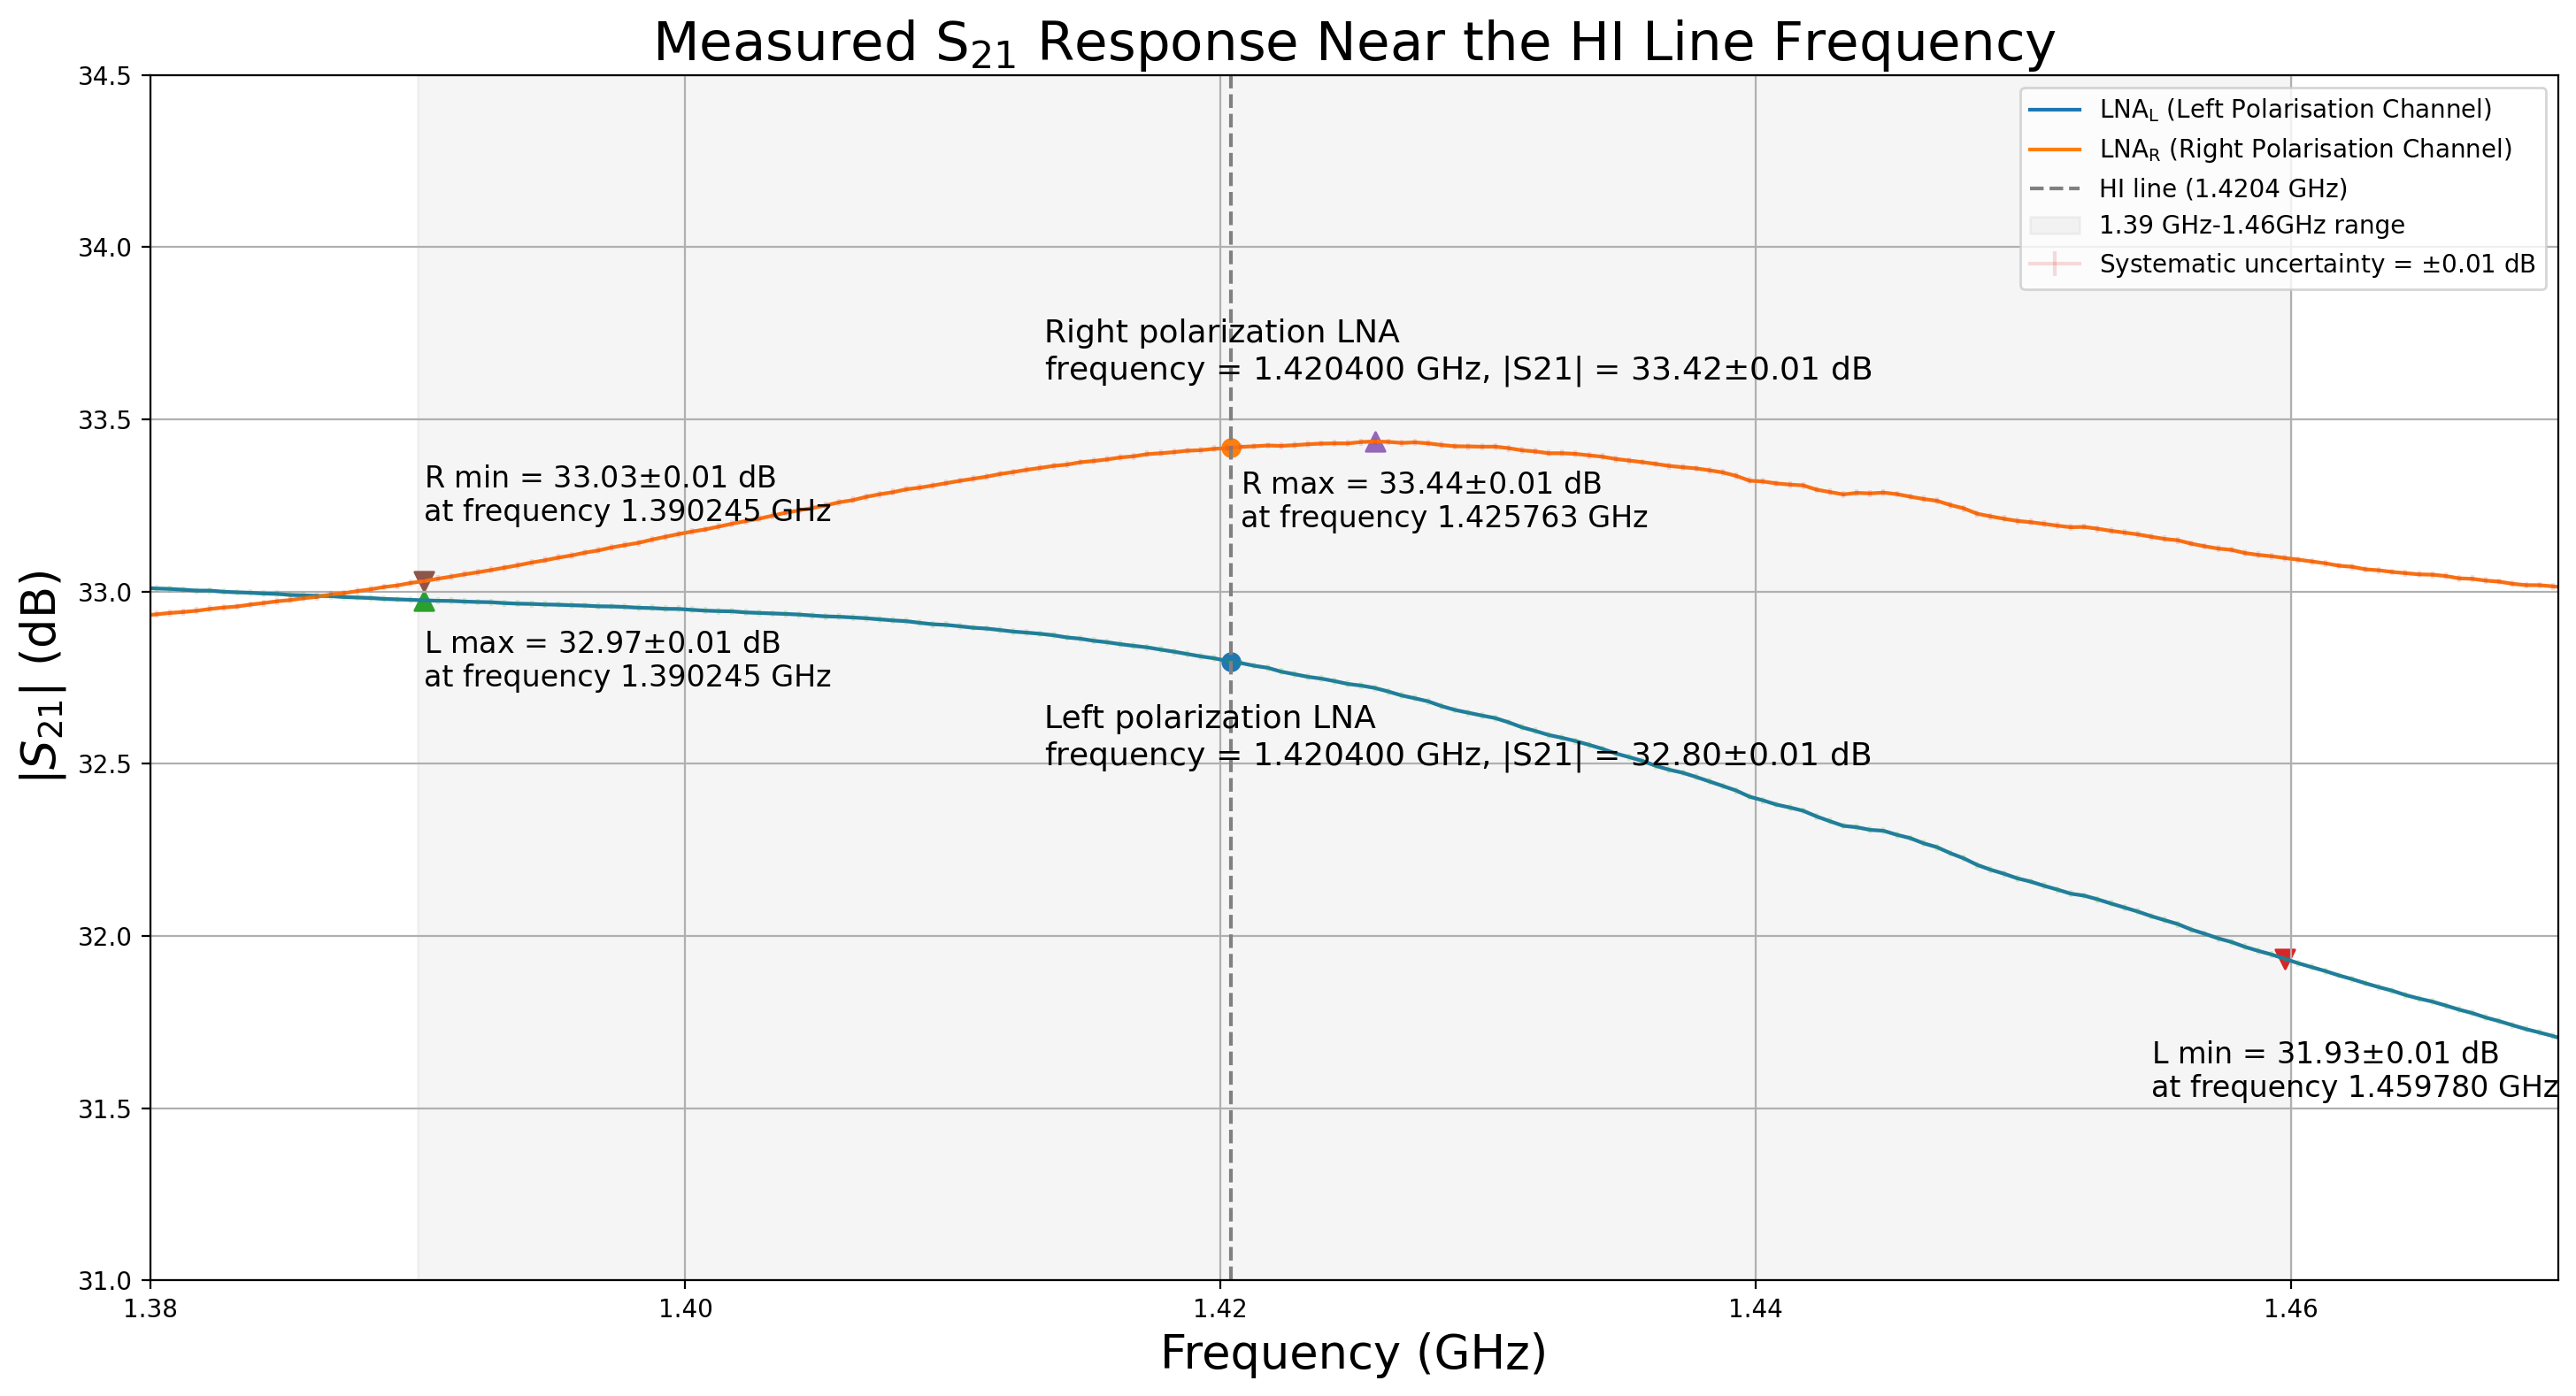

In [15]:
plt.figure(figsize=(15,8))

plt.plot(black_1g["freq_Hz"]/1e9,black_1g["mag_dB_corr"],label="LNA$_\\mathrm{L}$ (Left Polarisation Channel)")
plt.plot(red_1g["freq_Hz"]/1e9,red_1g["mag_dB_corr"],label="LNA$_\\mathrm{R}$ (Right Polarisation Channel)")

plt.errorbar(black_1g["freq_Hz"]/1e9,black_1g["mag_dB_corr"],yerr=0.01,alpha=0.16)
plt.errorbar(red_1g["freq_Hz"]/1e9,red_1g["mag_dB_corr"],yerr=0.01,alpha=0.16,label=r"Systematic uncertainty = $\pm 0.01$ dB")

plt.axvline(target_freq/1e9,linestyle="--",color="gray",label="HI line (1.4204 GHz)")
plt.axvspan(r_min_g,r_max_g,alpha=0.08,color="gray",label="1.39 GHz-1.46GHz range")

plt.scatter(target_freq/1e9,b_gain,s=50)
plt.annotate(f"Left polarization LNA\nfrequency = {target_freq/1e9:.6f} GHz, |S21| = {b_gain:.2f}$\pm0.01$ dB",
             xy=(target_freq/1e9,b_gain),
             xytext=(target_freq/1e9-0.007,b_gain-0.3),
             fontsize=13)

plt.scatter(target_freq/1e9,r_gain,s=50)
plt.annotate(f"Right polarization LNA\nfrequency = {target_freq/1e9:.6f} GHz, |S21| = {r_gain:.2f}$\pm0.01$ dB",
             xy=(target_freq/1e9,r_gain),
             xytext=(target_freq/1e9-0.007,r_gain+0.2),
             fontsize=13)

plt.scatter(b_s["max_freq_Hz"]/1e9,b_s["max_val_dB"],s=60,marker="^")
plt.scatter(b_s["min_freq_Hz"]/1e9,b_s["min_val_dB"],s=60,marker="v")
plt.scatter(r_s["max_freq_Hz"]/1e9,r_s["max_val_dB"],s=60,marker="^")
plt.scatter(r_s["min_freq_Hz"]/1e9,r_s["min_val_dB"],s=60,marker="v")

plt.annotate(f"L max = {b_s['max_val_dB']:.2f}$\pm0.01$ dB\nat frequency {b_s['max_freq_Hz']/1e9:.6f} GHz",
             xy=(b_s["max_freq_Hz"]/1e9,b_s["max_val_dB"]),xytext=(b_s["max_freq_Hz"]/1e9,b_s["max_val_dB"]-0.25),fontsize=12)
plt.annotate(f"L min = {b_s['min_val_dB']:.2f}$\pm0.01$ dB\nat frequency {b_s['min_freq_Hz']/1e9:.6f} GHz",
             xy=(b_s["min_freq_Hz"]/1e9,b_s["min_val_dB"]),xytext=(b_s["min_freq_Hz"]/1e9-0.005,b_s["min_val_dB"]-0.4),
             fontsize=12)
plt.annotate(f"R max = {r_s['max_val_dB']:.2f}$\pm0.01$ dB\nat frequency {r_s['max_freq_Hz']/1e9:.6f} GHz",
             xy=(r_s["max_freq_Hz"]/1e9,r_s["max_val_dB"]),xytext=(r_s["max_freq_Hz"]/1e9-0.005,r_s["max_val_dB"]-0.25),
             fontsize=12)
plt.annotate(f"R min = {r_s['min_val_dB']:.2f}$\pm0.01$ dB\nat frequency {r_s['min_freq_Hz']/1e9:.6f} GHz",
             xy=(r_s["min_freq_Hz"]/1e9,r_s["min_val_dB"]),xytext=(r_s["min_freq_Hz"]/1e9,r_s["min_val_dB"]+0.175),
             fontsize=12)

plt.xlabel("Frequency (GHz)",fontsize=19)
plt.ylabel(r"$|S_{21}|$ (dB)",fontsize=19)
plt.xlim(1.38,1.47)
plt.ylim(31,34.5)
plt.title("Measured S$_{21}$ Response Near the HI Line Frequency",fontsize=22)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
red_interp_full = np.interp( black_1g["freq_Hz"], red_1g["freq_Hz"], red_1g["mag_dB_corr"])
delta_curve = red_interp_full - black_1g["mag_dB_corr"].values

delta_at_HI = np.interp(1.4204e9, black_1g["freq_Hz"], delta_curve)


mask_below = black_1g["freq_Hz"].values < 1.42e9
delta_below_mean = np.mean(delta_curve[mask_below])
delta_below_std  = np.std(delta_curve[mask_below])


mask_above = black_1g["freq_Hz"].values > 1.42e9
delta_above_max = np.max(delta_curve[mask_above])

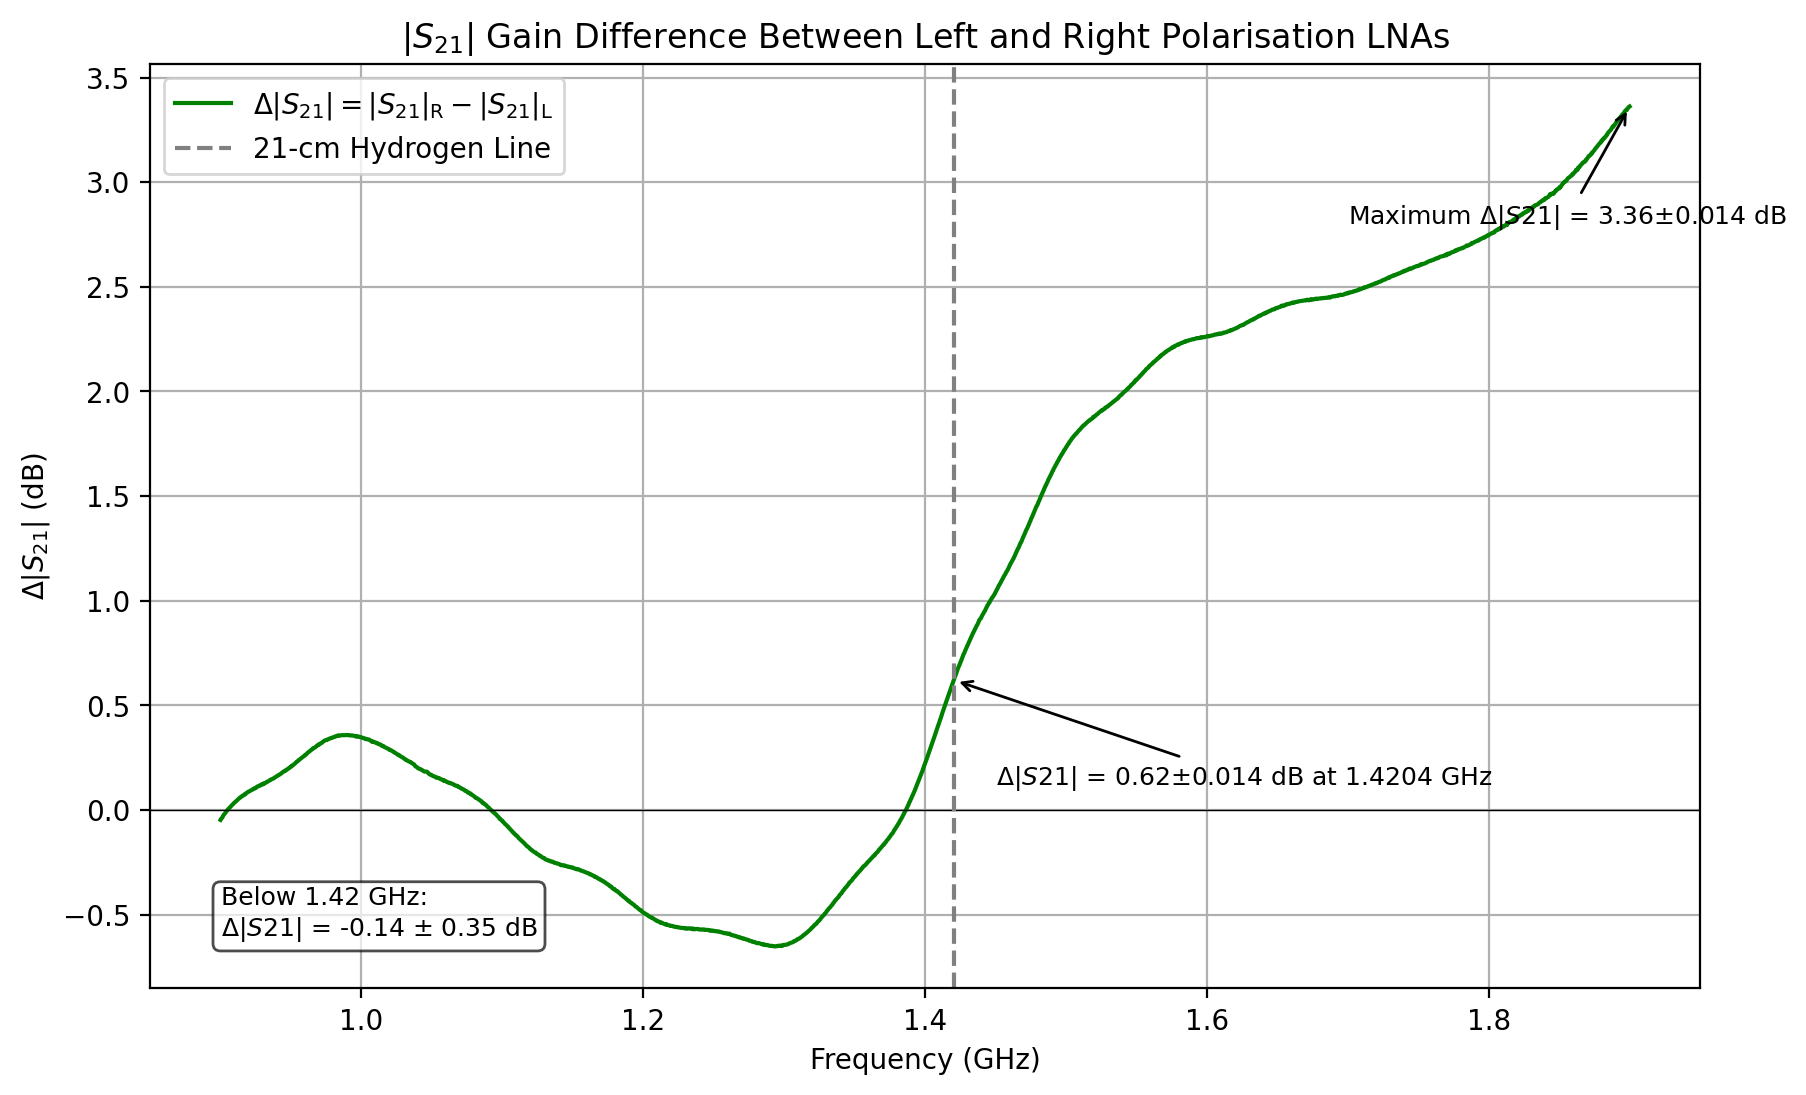

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(black_1g["freq_Hz"]/1e9, delta_curve, color='green',label=r"$\Delta|S_{21}| = |S_{21}|_\mathrm{R} - |S_{21}|_\mathrm{L}$")
ax.set_title(r"$|S_{21}|$ Gain Difference Between Left and Right Polarisation LNAs")
ax.axhline(0, color='k', lw=0.5)
ax.axvline(1.4204, color='gray', linestyle='--', label='21-cm Hydrogen Line')

ax.annotate(f"$\Delta |S21|$ = {delta_at_HI:.2f}$\pm0.014$ dB at 1.4204 GHz",xy=(1.4204, delta_at_HI),xytext=(1.45, delta_at_HI - 0.5),arrowprops=dict(arrowstyle="->"), fontsize=9)

ax.annotate(f"Below 1.42 GHz:\n$\Delta|S21|$ = {delta_below_mean:.2f} ± {delta_below_std:.2f} dB",xy=(1.1, delta_below_mean),xytext=(0.9, -0.6), fontsize=9,bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

ax.annotate(f"Maximum $\Delta|S21|$ = {delta_above_max:.2f}$\pm0.014$ dB",xy=(black_1g["freq_Hz"].values[np.argmax(delta_curve[mask_above]) + mask_above.argmax()] / 1e9,delta_above_max),xytext=(1.7, 2.8), fontsize=9,arrowprops=dict(arrowstyle="->"))


ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel(r"$\Delta|S_{21}|$ (dB)")
ax.legend(); ax.grid(True)

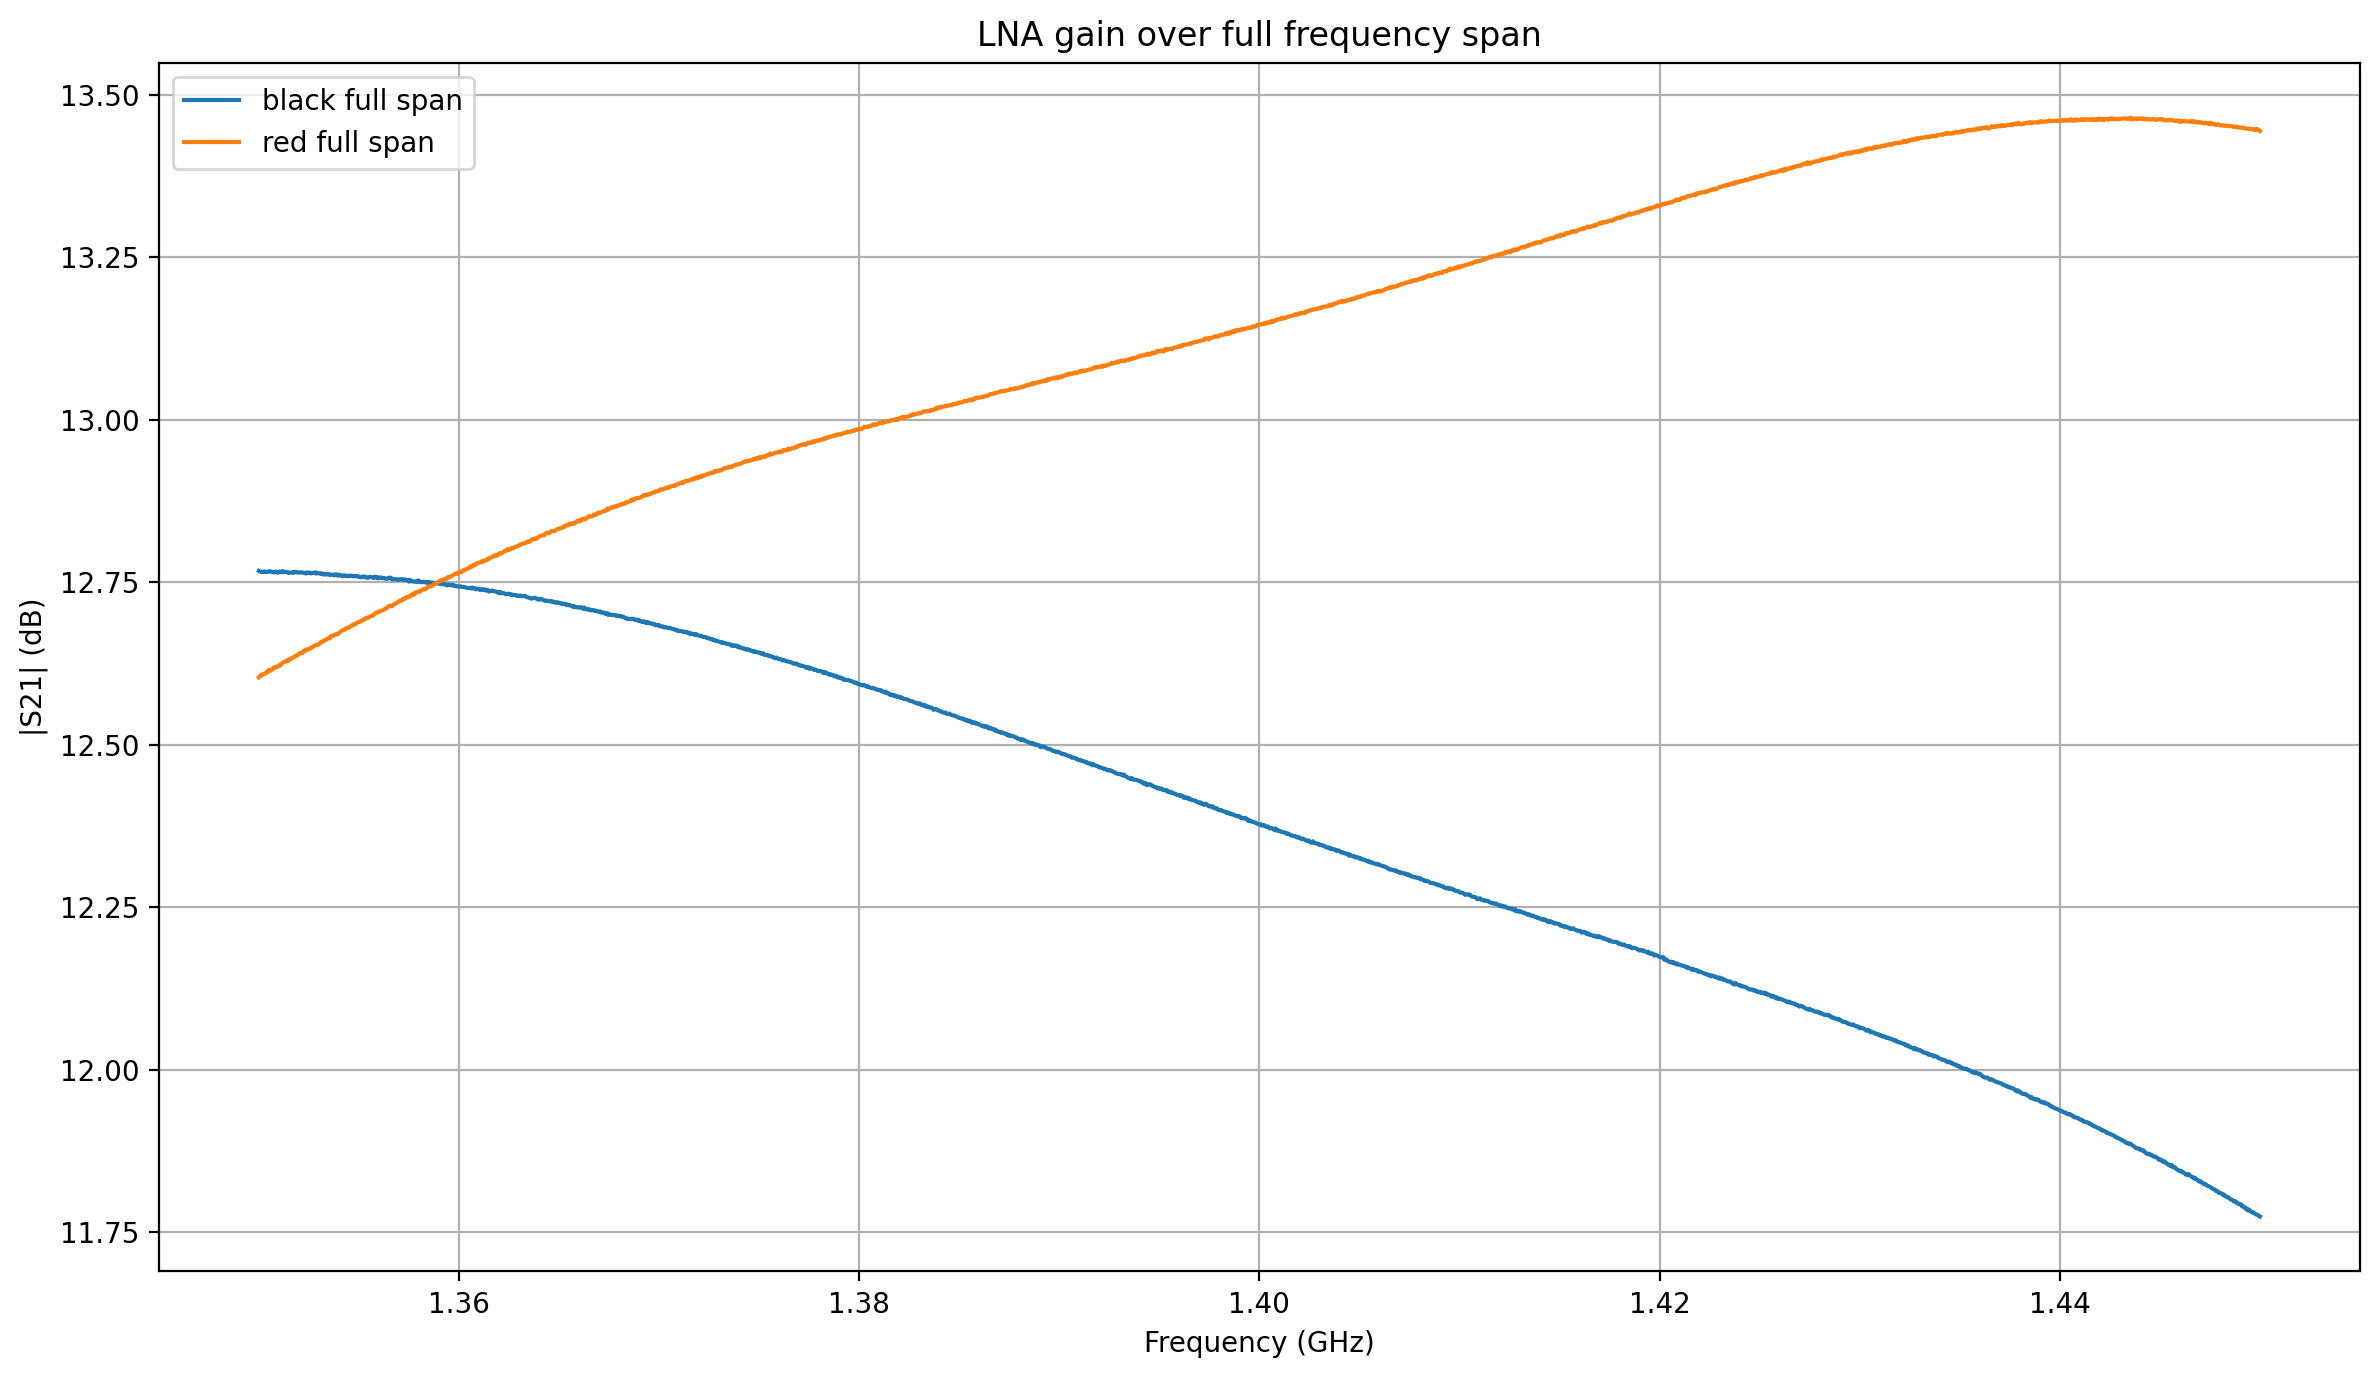

In [20]:
#full span
plt.figure()
plt.plot(black_all["freq_Hz"]/1e9, black_all["mag_dB"]+10, label="black full span")
plt.plot(red_all["freq_Hz"]/1e9,   red_all["mag_dB"]+10,   label="red full span")
plt.xlabel("Frequency (GHz)")
plt.ylabel("|S21| (dB)")
plt.title("LNA gain over full frequency span")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()